
NaN values per column:
Timestamp                 0
VALCCG:D11_L21:PRES    2755
VALCCG:D11_L20:PRES    2755
VALCCG:D11_L22:PRES    2755
VALCCG:D11_L23:PRES    2755
VALCCG:D11_L24:PRES    2755
VALCCG:D11_L25:PRES    2755
VALCCG:D11_L19:PRES    2755
VALCCG:D11_L18:PRES    3881
VALCCG:D11_L17:PRES    2755
VALCCG:D11_L16:PRES    4157
VALCCG:D11_L15:PRES    4569
VALCCG:D11_L14:PRES    4216
VALCCG:D11_L13:PRES    4370
VALCCG:D11_L12:PRES    4569
VALCCG:D11_L11:PRES    4365
VALCCG:D11_L10:PRES    3031
VALCCG:D11_L09:PRES    4519
VALCCG:D11_L08:PRES    4322
VALCCG:D11_L07:PRES    4351
VALCCG:D11_L06:PRES    4252
VALCCG:D11_L05:PRES    4302
VALCCG:D11_L04:PRES    4367
VALCCG:D11_L03:PRES    4324
VALCCG:D11_L02:PRES    4272
VALCCG:D11_L01:PRES    4328
dtype: int64

Reference channel: VALCCG:D11_L21:PRES
VALCCG:D11_L21:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L20:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L22:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L23:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L24:PRES / VALCC

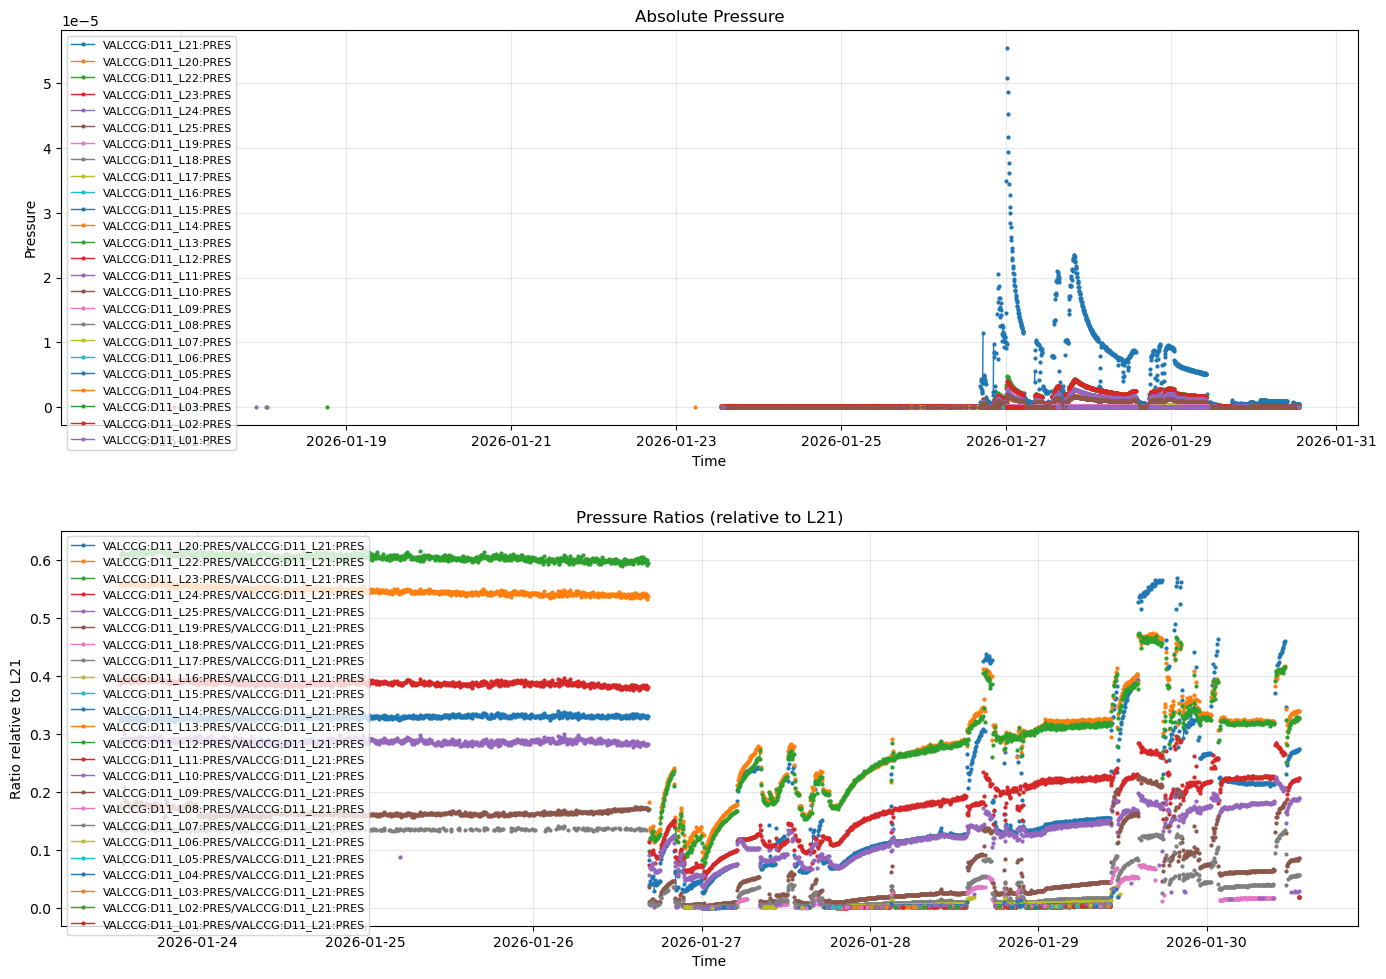

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
vac = pd.read_csv('/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv')

# Assuming the first column is time and the rest are channels
time_col = vac.columns[0]
channel_cols = vac.columns[1:]

# Convert time column to datetime
vac[time_col] = pd.to_datetime(vac[time_col])

# Check for NaN values
print(f"\nNaN values per column:")
print(vac.isna().sum())

# Find the L21 column (reference channel)
l21_col = [col for col in channel_cols if '_L21:' in col][0]
print(f"\nReference channel: {l21_col}")

# Calculate ratios relative to L21
ratio_data = {}
for channel in channel_cols:
    ratio_data[channel] = vac[channel] / vac[l21_col]
    print(f"{channel} / {l21_col}")

# Create two subplots - one for absolute values, one for ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot absolute pressure values
for channel in channel_cols:
    ax1.plot(vac[time_col], vac[channel], linewidth=1, label=channel, marker='o', markersize=2)

ax1.set_xlabel('Time')
ax1.set_ylabel('Pressure')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_title('Absolute Pressure')

# Plot ratios relative to L21
for channel in channel_cols:
    if channel != l21_col:  # Don't plot L21/L21 (which is always 1)
        ax2.plot(vac[time_col], ratio_data[channel], linewidth=1, label=f"{channel}/{l21_col}", marker='o', markersize=2)

ax2.set_xlabel('Time')
ax2.set_ylabel('Ratio relative to L21')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_title('Pressure Ratios (relative to L21)')

plt.tight_layout()
plt.show()

Detected 0 pressure events.


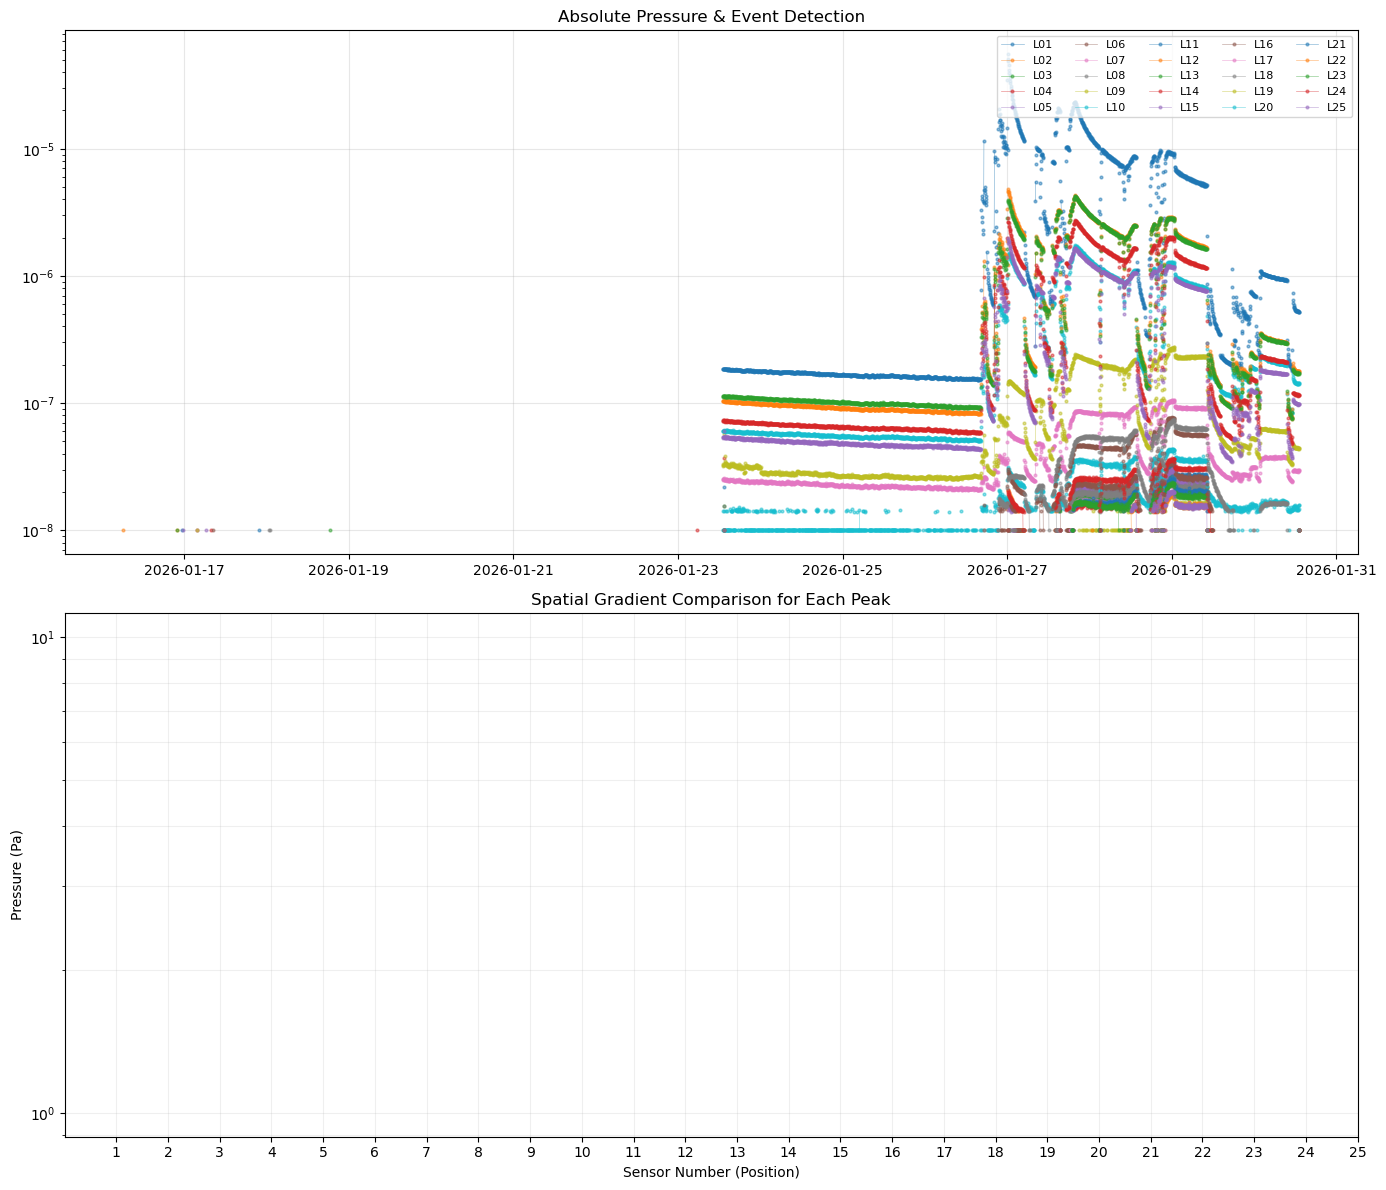

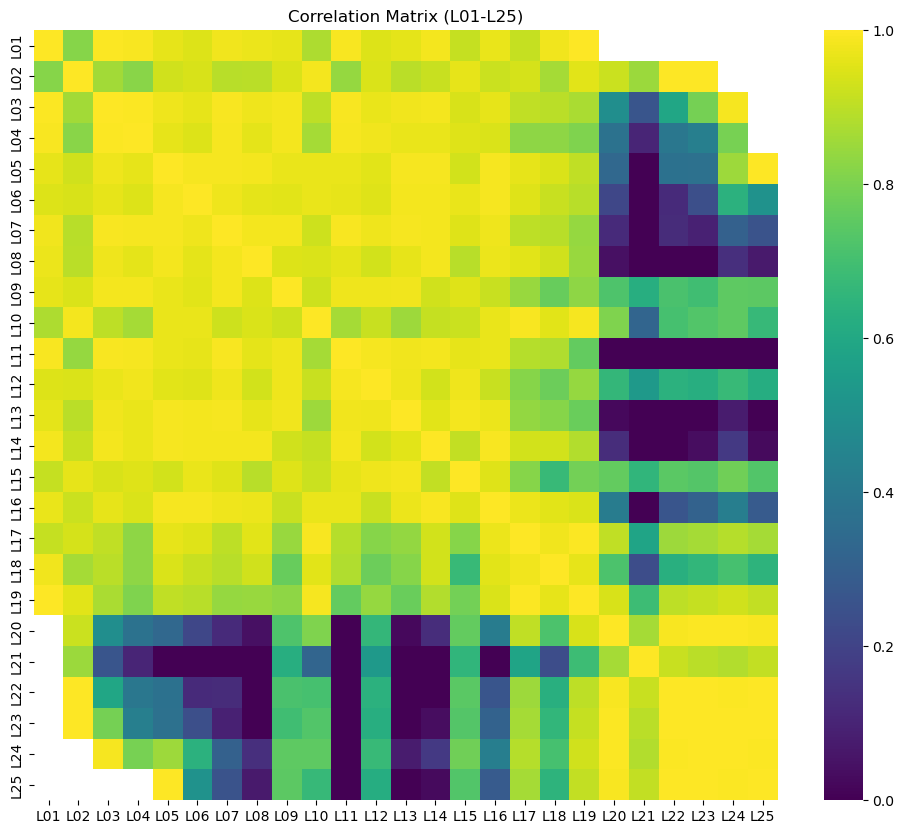

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# --- 1. Load and Clean Data ---
# Ensure your path is correct
try:
    vac = pd.read_csv('/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv')
except FileNotFoundError:
    print("File not found. Please check the path.")

time_col = vac.columns[0]
channel_cols = vac.columns[1:]
vac[time_col] = pd.to_datetime(vac[time_col])

# --- 2. Helper for Spatial Mapping ---
def extract_sensor_num(col_name):
    match = re.search(r'_L(\d+):', col_name)
    return int(match.group(1)) if match else None

# Organize sensors L01 to L25
sensor_info = sorted([{'col': c, 'num': extract_sensor_num(c)} for c in channel_cols if extract_sensor_num(c) is not None], key=lambda x: x['num'])
sorted_cols = [s['col'] for s in sensor_info]
sensor_nums = [s['num'] for s in sensor_info]
l21_col = next((s['col'] for s in sensor_info if s['num'] == 21), None)

# --- 3. Robust Peak Detection (No SciPy needed) ---
# We find local maxima by comparing a value to its neighbors in L21
# This is a basic "find peaks" logic using a 50-point window
window = 50 
vac['L21_max'] = vac[l21_col].rolling(window=window, center=True).max()
peak_mask = (vac[l21_col] == vac['L21_max']) & (vac[l21_col] > vac[l21_col].quantile(0.95))
peak_indices = vac.index[peak_mask].tolist()

# Filter peak_indices to avoid getting multiple points for the same "hump"
filtered_peaks = []
if peak_indices:
    filtered_peaks.append(peak_indices[0])
    for i in range(1, len(peak_indices)):
        if peak_indices[i] - peak_indices[i-1] > window:
            filtered_peaks.append(peak_indices[i])

print(f"Detected {len(filtered_peaks)} pressure events.")

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: Absolute Pressure
for s in sensor_info:
    ax1.plot(vac[time_col], vac[s['col']], label=f"L{s['num']:02d}", marker='o', markersize=2, linewidth=0.5, alpha=0.5)

# Mark the detected peaks
if filtered_peaks:
    ax1.scatter(vac[time_col].iloc[filtered_peaks], vac[l21_col].iloc[filtered_peaks], 
                color='red', marker='x', s=40, label='Analyzed Peaks', zorder=10)

ax1.set_title('Absolute Pressure & Event Detection')
ax1.set_yscale('log')
ax1.legend(ncol=5, fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Spatial Gradient for EACH Peak
colors = plt.cm.plasma(np.linspace(0, 0.8, len(filtered_peaks)))
for i, idx in enumerate(filtered_peaks):
    snapshot = vac[sorted_cols].iloc[idx].values
    time_str = vac[time_col].iloc[idx].strftime('%H:%M')
    ax2.plot(sensor_nums, snapshot, marker='o', markersize=2, linestyle='-', 
             linewidth=1.2, alpha=0.8, color=colors[i], label=f'Peak @ {time_str}')

ax2.set_yscale('log')
ax2.set_xlabel('Sensor Number (Position)')
ax2.set_ylabel('Pressure (Pa)')
ax2.set_title('Spatial Gradient Comparison for Each Peak')
ax2.set_xticks(range(1, 26))
ax2.grid(True, which="both", ls="-", alpha=0.2)
if filtered_peaks:
    ax2.legend(fontsize=8, loc='best', ncol=2)

plt.tight_layout()
plt.show()

# --- 5. Heatmap (Full 25-Channel Range) ---
plt.figure(figsize=(12, 10))
corr = vac[sorted_cols].corr()
sns.heatmap(corr, annot=False, cmap='viridis', vmin=0, vmax=1,
            xticklabels=[f"L{n:02d}" for n in sensor_nums], 
            yticklabels=[f"L{n:02d}" for n in sensor_nums])
plt.title('Correlation Matrix (L01-L25)')
plt.show()

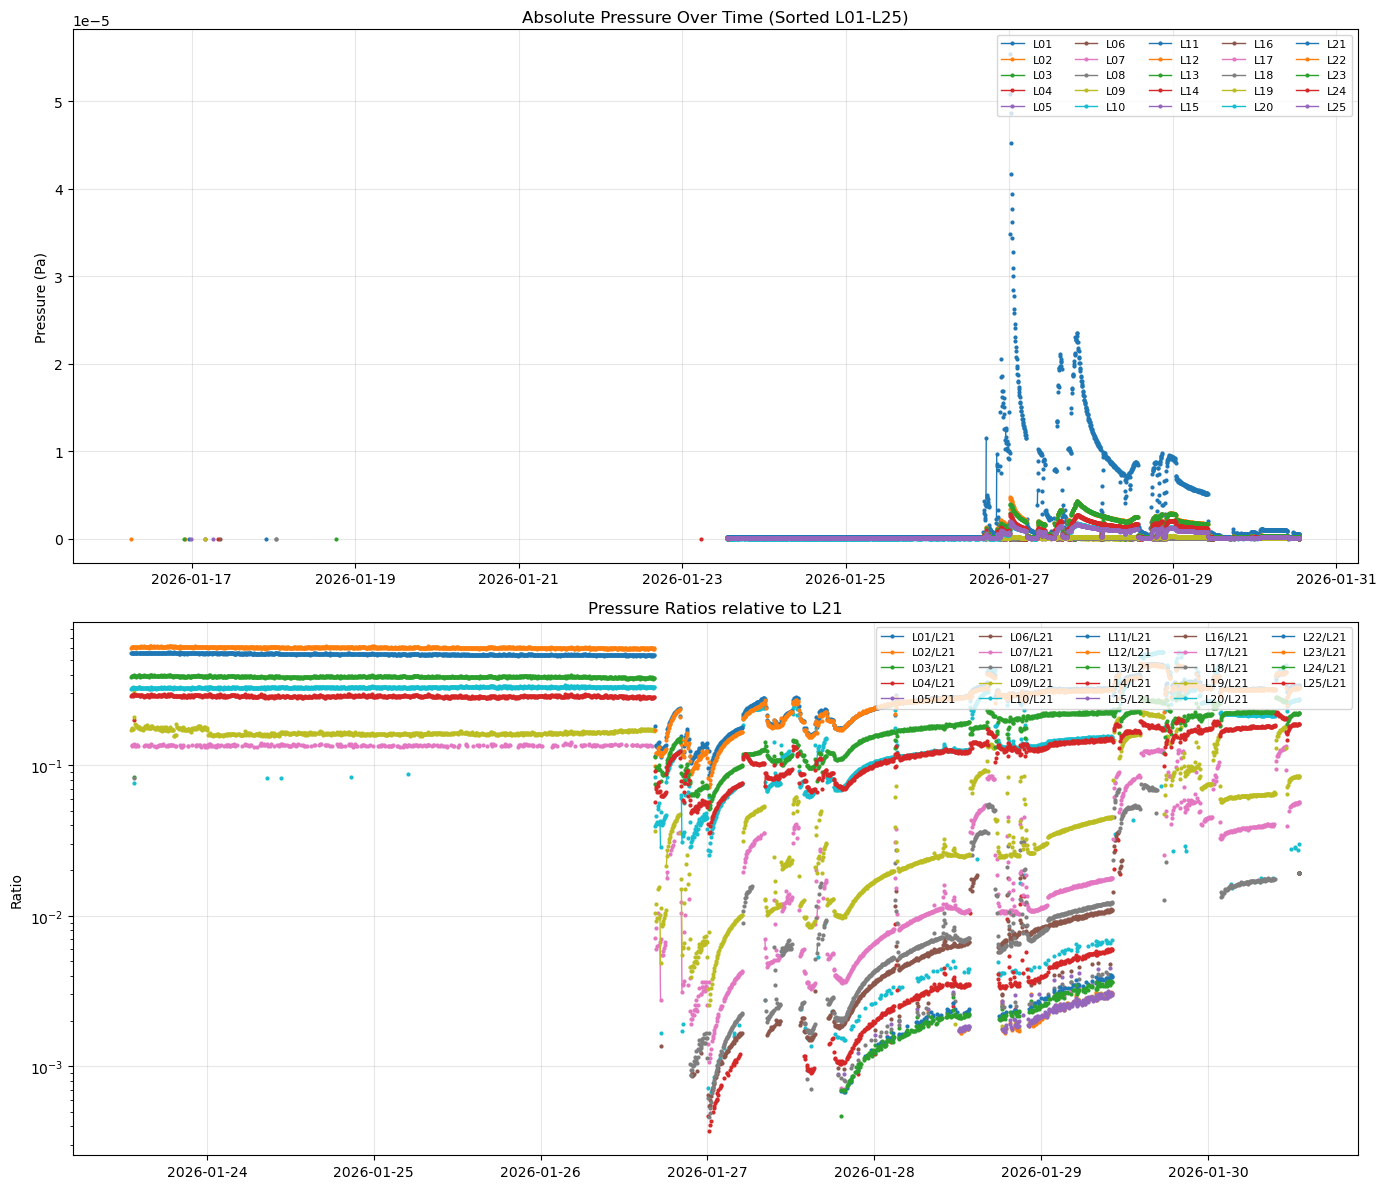

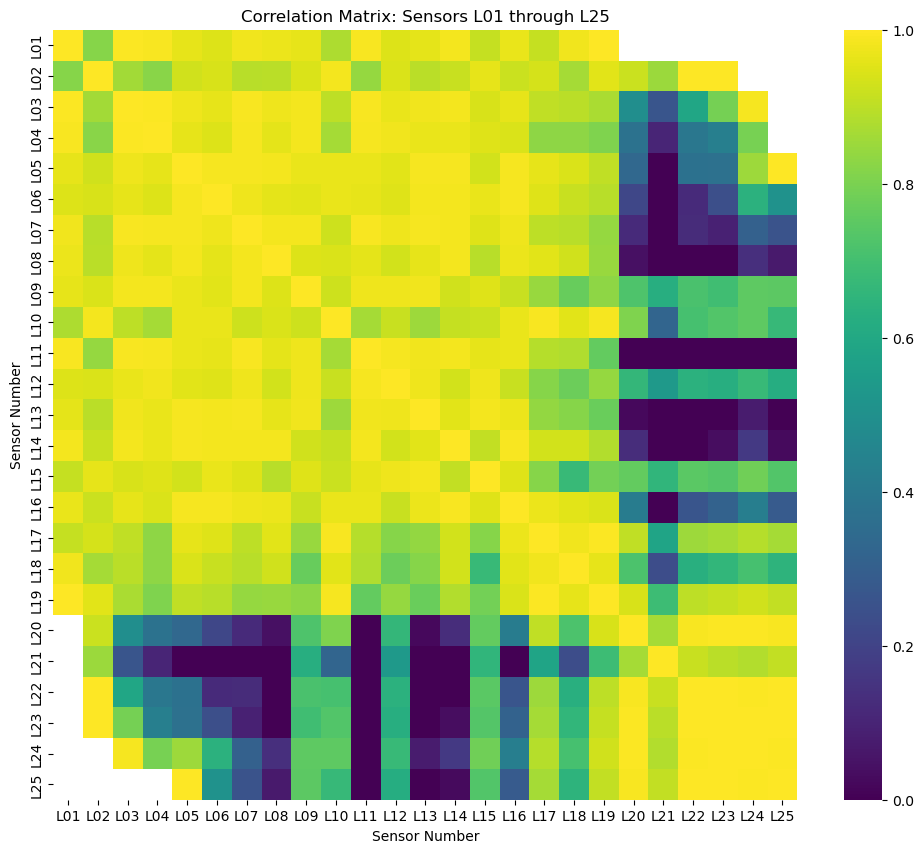

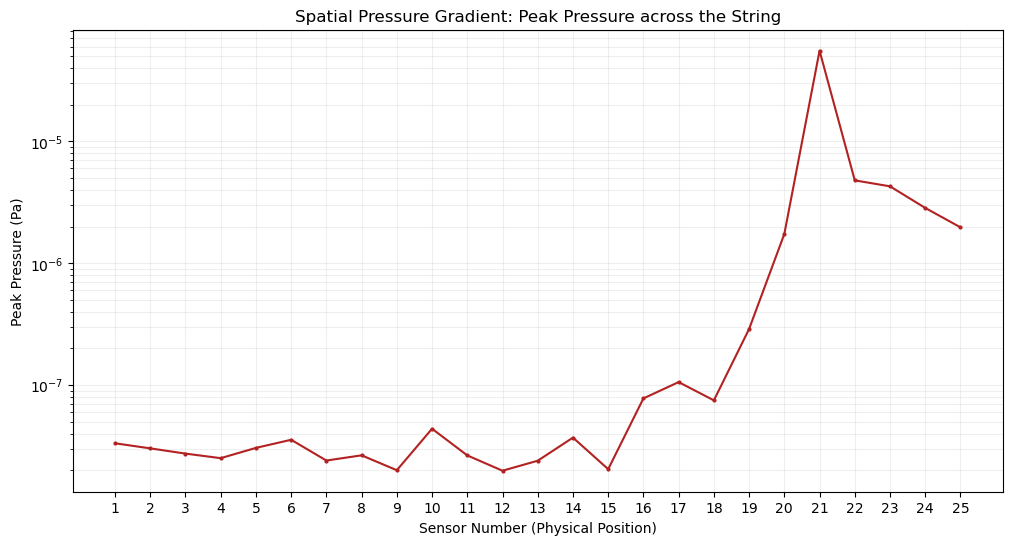

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. Load and Clean Data ---
# Note: Ensure the path matches your local environment
vac = pd.read_csv('/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv')

time_col = vac.columns[0]
channel_cols = vac.columns[1:]
vac[time_col] = pd.to_datetime(vac[time_col])

# --- 2. Helper for Spatial Mapping ---
def extract_sensor_num(col_name):
    """Extracts the numeric part of the label (e.g., L21 -> 21)."""
    match = re.search(r'_L(\d+):', col_name)
    return int(match.group(1)) if match else None

# Map channels and sort them numerically 1 through 25
sensor_info = []
for col in channel_cols:
    num = extract_sensor_num(col)
    if num is not None:
        sensor_info.append({'col': col, 'num': num})

# Sort by sensor number (L01, L02, ..., L25)
sensor_info = sorted(sensor_info, key=lambda x: x['num'])
sorted_cols = [s['col'] for s in sensor_info]
short_labels = [f"L{s['num']:02d}" for s in sensor_info]

# --- 3. Visualization: Absolute & Ratios ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Identify L21 reference channel
l21_col = next((s['col'] for s in sensor_info if s['num'] == 21), None)

for s in sensor_info:
    col = s['col']
    lbl = f"L{s['num']:02d}"
    
    # Plot Absolute
    ax1.plot(vac[time_col], vac[col], label=lbl, marker='o', markersize=2, linewidth=1)
    
    # Plot Ratios (relative to L21)
    if l21_col and col != l21_col:
        ax2.plot(vac[time_col], vac[col] / vac[l21_col], label=f"{lbl}/L21", marker='o', markersize=2, linewidth=1)

ax1.set_title('Absolute Pressure Over Time (Sorted L01-L25)')
ax1.set_ylabel('Pressure (Pa)')
ax1.legend(ncol=5, fontsize=8, loc='upper right', frameon=True)
ax1.grid(True, alpha=0.3)

ax2.set_title('Pressure Ratios relative to L21')
ax2.set_ylabel('Ratio')
ax2.set_yscale('log')
ax2.legend(ncol=5, fontsize=8, loc='upper right', frameon=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. Correlation Analysis (Full 1-25 Matrix) ---
plt.figure(figsize=(12, 10))
# Calculate Pearson correlation on the sorted columns
corr = vac[sorted_cols].corr()
corr.index = short_labels
corr.columns = short_labels

# Using a diverging color map to highlight deviations from perfect correlation (1.0)
sns.heatmap(corr, annot=False, cmap='viridis', vmin=0, vmax=1)
plt.title('Correlation Matrix: Sensors L01 through L25')
plt.xlabel('Sensor Number')
plt.ylabel('Sensor Number')
plt.show()

# --- 5. Spatial Gradient Analysis ---
peak_pressures = [vac[col].max() for col in sorted_cols]
sensor_nums = [s['num'] for s in sensor_info]

plt.figure(figsize=(12, 6))
plt.plot(sensor_nums, peak_pressures, marker='o', markersize=2, linestyle='-', color='firebrick', linewidth=1.5)

plt.yscale('log')
plt.xlabel('Sensor Number (Physical Position)')
plt.ylabel('Peak Pressure (Pa)')
plt.title('Spatial Pressure Gradient: Peak Pressure across the String')
plt.xticks(range(1, 26)) # Force showing all 25 ticks
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Total events detected: 5


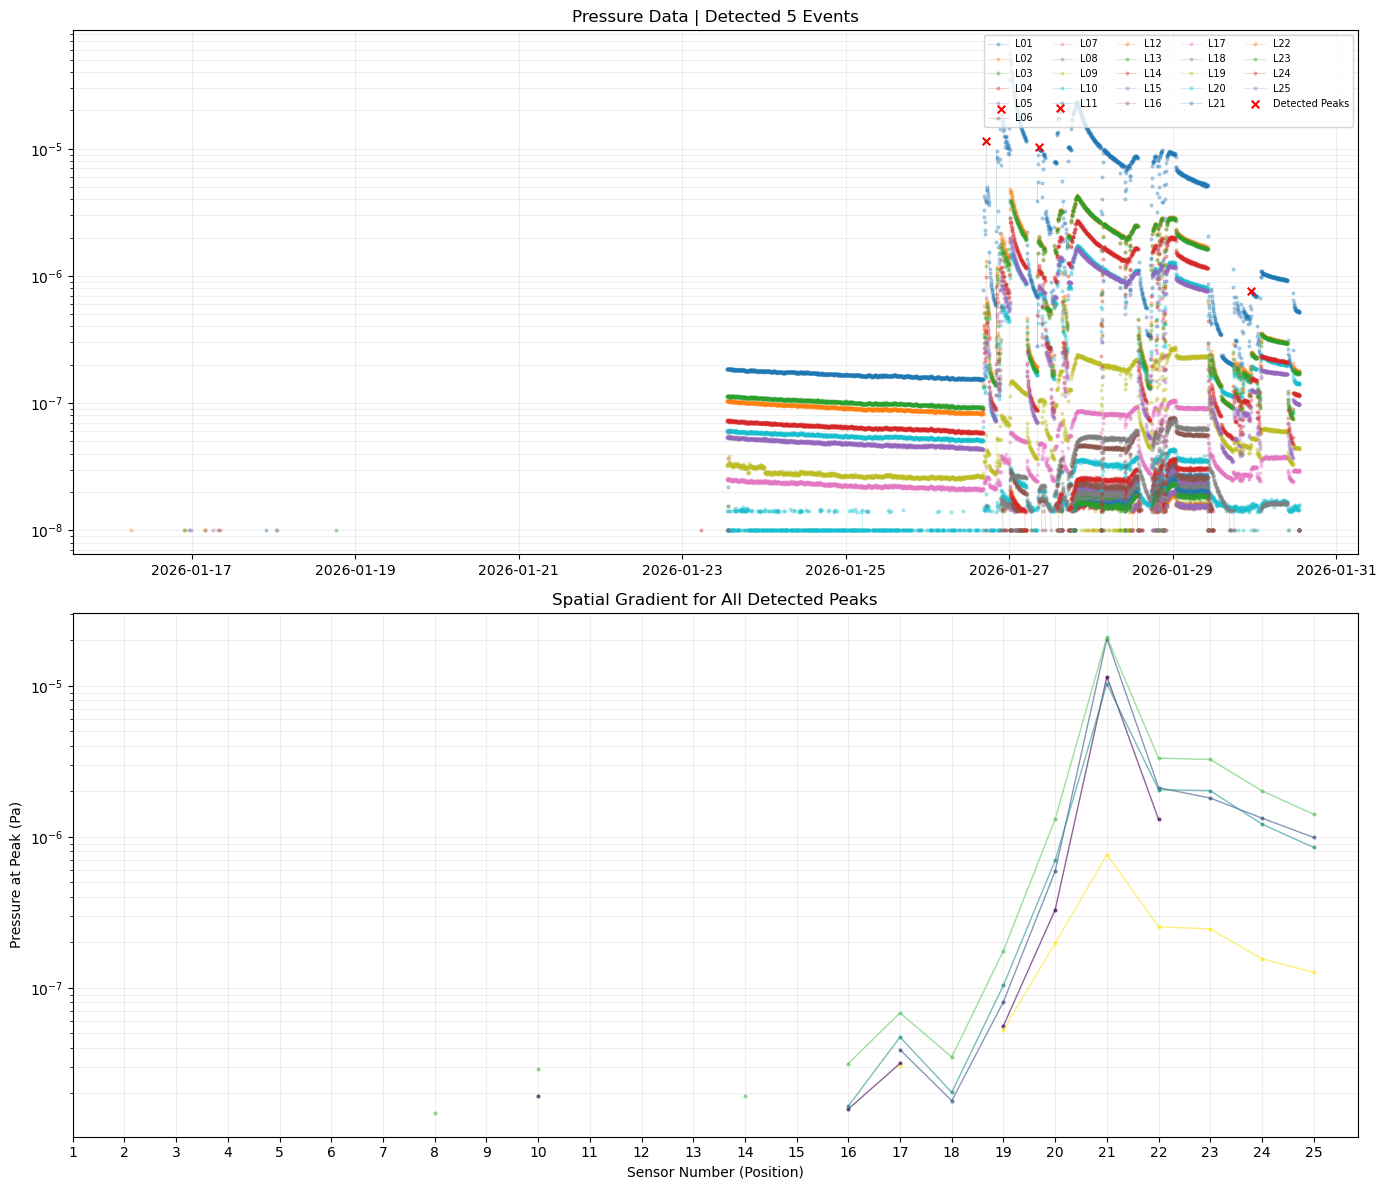

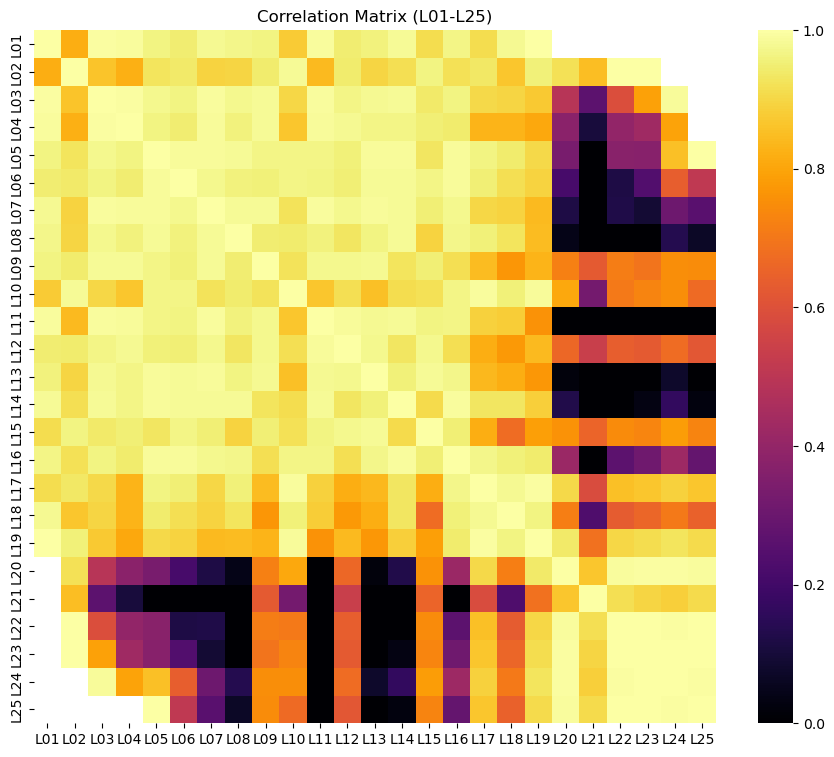

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# --- 1. Load and Prep ---
file_path = '/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv'
vac = pd.read_csv(file_path)
vac.columns = [c.strip() for c in vac.columns]
time_col = vac.columns[0]
vac[time_col] = pd.to_datetime(vac[time_col])

# --- 2. Extract Channels L01-L25 ---
sensor_info = sorted([{'col': c, 'num': int(re.search(r'L(\d+)', c).group(1))} 
                     for c in vac.columns[1:] if re.search(r'L(\d+)', c)], 
                     key=lambda x: x['num'])
sorted_cols = [s['col'] for s in sensor_info]
sensor_nums = [s['num'] for s in sensor_info]
l21_col = next((s['col'] for s in sensor_info if s['num'] == 21), None)

# --- 3. High-Sensitivity Peak Detection ---
# Calculate the first derivative (rate of rise)
dy = vac[l21_col].diff()

# Set a more sensitive threshold (top 5% of all positive pressure changes)
rise_threshold = dy[dy > 0].quantile(0.90) 
min_gap = 20  # Minimum samples between separate events

event_indices = []
last_found = -min_gap

for i in range(1, len(dy)):
    if dy.iloc[i] > rise_threshold and (i - last_found) > min_gap:
        # Search for the local peak in a small window (e.g., next 100 samples)
        window_end = min(i + 100, len(vac))
        peak_idx = vac[l21_col].iloc[i:window_end].idxmax()
        
        # Only add if it's a significant peak compared to its immediate start
        if vac[l21_col].iloc[peak_idx] > vac[l21_col].iloc[i-1] * 1.05:
            event_indices.append(peak_idx)
            last_found = peak_idx

print(f"Total events detected: {len(event_indices)}")

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: Raw Pressure with Markers
for s in sensor_info:
    # Use markersize=2 as requested
    ax1.plot(vac[time_col], vac[s['col']], label=f"L{s['num']:02d}", marker='o', markersize=2, linewidth=0.5, alpha=0.3)

if event_indices:
    ax1.scatter(vac[time_col].iloc[event_indices], vac[l21_col].iloc[event_indices], 
                color='red', marker='x', s=30, label='Detected Peaks', zorder=10)

ax1.set_yscale('log')
ax1.set_title(f'Pressure Data | Detected {len(event_indices)} Events')
ax1.legend(ncol=5, fontsize=7, loc='upper right', frameon=True)
ax1.grid(True, which="both", alpha=0.2)

# Subplot 2: Spatial Gradient (One line per peak)
# Using a colormap that can handle many lines
colors = plt.cm.viridis(np.linspace(0, 1, len(event_indices)))

for i, idx in enumerate(event_indices):
    snapshot = vac[sorted_cols].iloc[idx].values
    ax2.plot(sensor_nums, snapshot, marker='o', markersize=2, linestyle='-', 
             linewidth=1, alpha=0.6, color=colors[i])

ax2.set_yscale('log')
ax2.set_xlabel('Sensor Number (Position)')
ax2.set_ylabel('Pressure at Peak (Pa)')
ax2.set_title('Spatial Gradient for All Detected Peaks')
ax2.set_xticks(range(1, 26))
ax2.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

# --- 5. Full Heatmap ---
plt.figure(figsize=(11, 9))
sns.heatmap(vac[sorted_cols].corr(), annot=False, cmap='inferno', vmin=0, vmax=1,
            xticklabels=[f"L{n:02d}" for n in sensor_nums], 
            yticklabels=[f"L{n:02d}" for n in sensor_nums])
plt.title('Correlation Matrix (L01-L25)')
plt.show()

Detected 17 peaks.


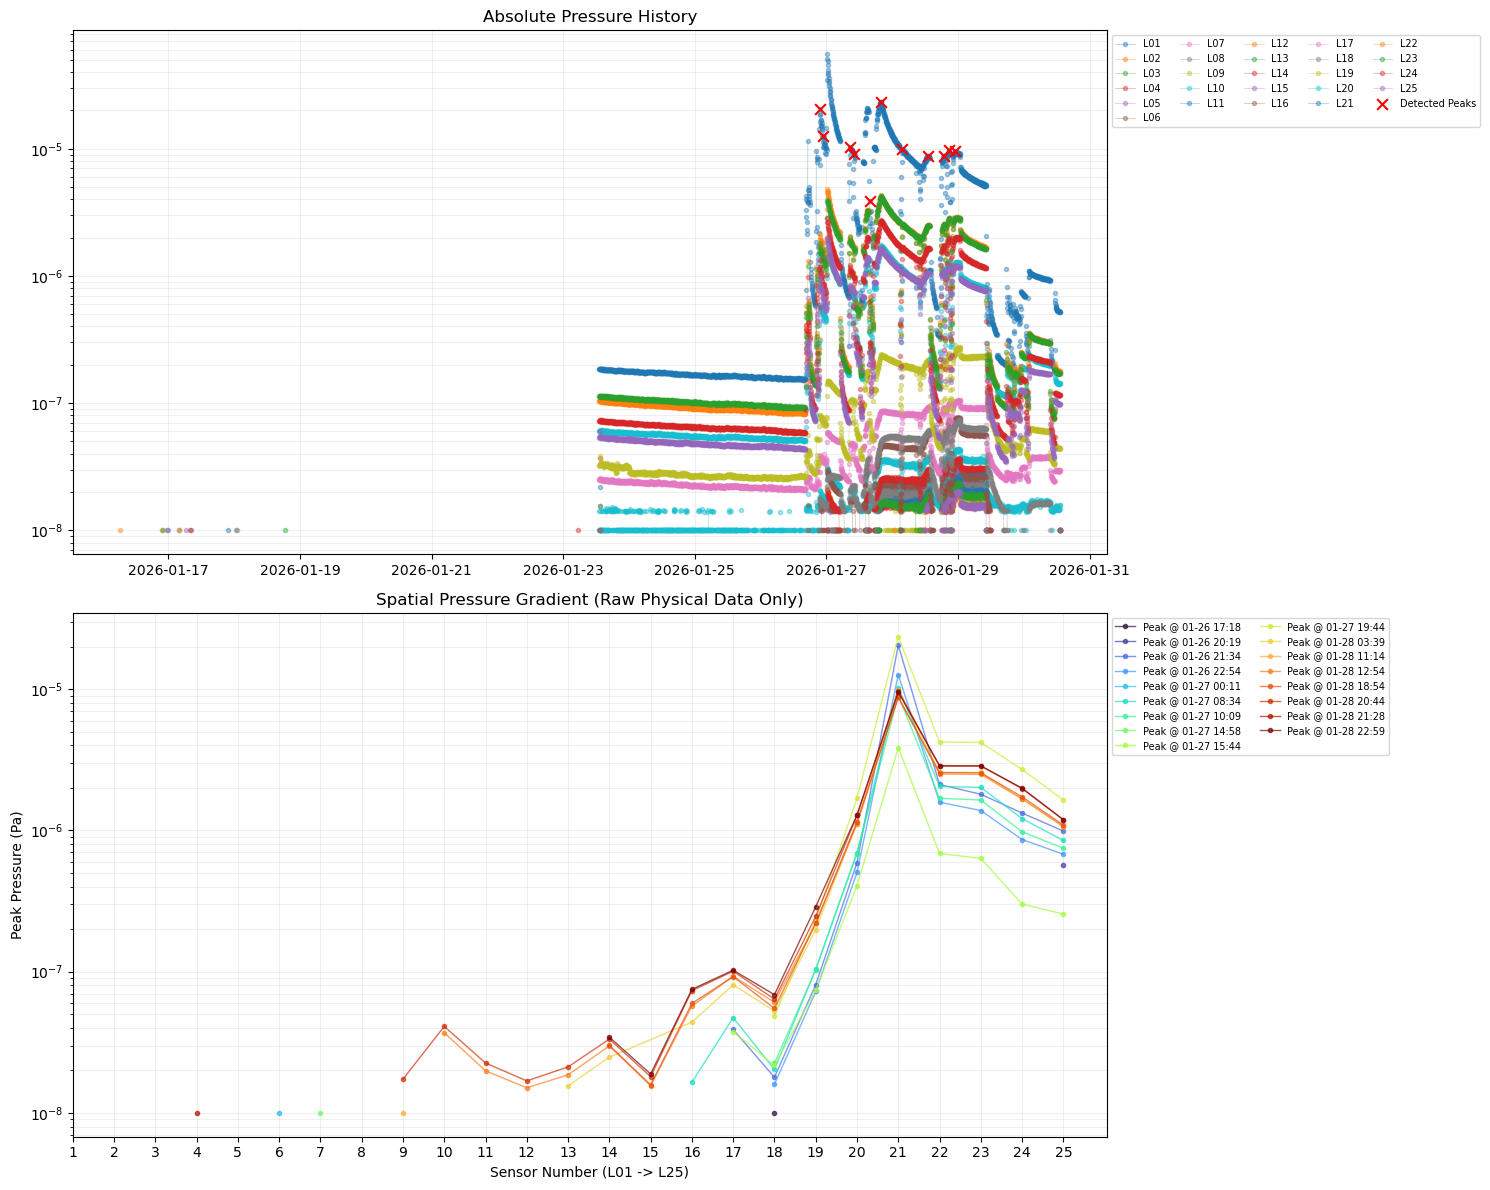

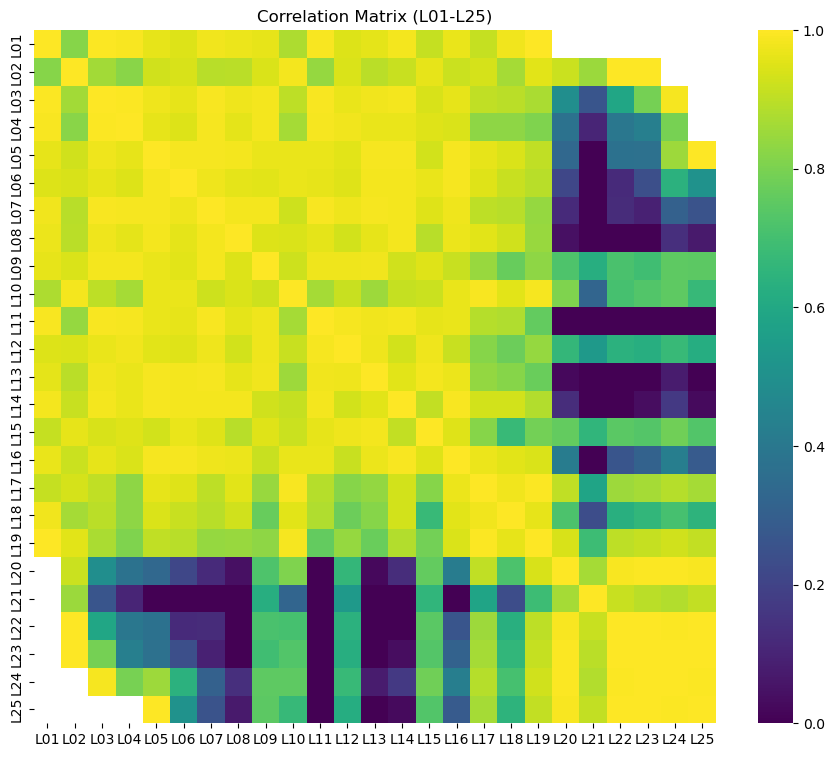

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from scipy.signal import find_peaks

# --- 1. Load and Prep ---
file_path = '/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv'
vac = pd.read_csv(file_path)
vac.columns = [c.strip() for c in vac.columns]
time_col = vac.columns[0]
vac[time_col] = pd.to_datetime(vac[time_col])

# --- 2. Extract Channels L01-L25 ---
sensor_info = sorted([{'col': c, 'num': int(re.search(r'L(\d+)', c).group(1))} 
                     for c in vac.columns[1:] if re.search(r'L(\d+)', c)], 
                     key=lambda x: x['num'])
sorted_cols = [s['col'] for s in sensor_info]
sensor_nums = [s['num'] for s in sensor_info]
l21_col = next((s['col'] for s in sensor_info if s['num'] == 21), sorted_cols[0])

# --- 3. High-Sensitivity Peak Detection ---
# Fill NaNs only for the detection algorithm to prevent "breaks" in the timeline
series_for_detection = vac[l21_col].ffill().bfill()

# Adjusted prominence to be very low to catch all the "humps" seen in your plot
peaks, _ = find_peaks(series_for_detection, 
                      prominence=series_for_detection.std() * 0.2, 
                      distance=30)

event_indices = peaks.tolist()
print(f"Detected {len(event_indices)} peaks.")

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Subplot 1: Time Series
for s in sensor_info:
    ax1.plot(vac[time_col], vac[s['col']], label=f"L{s['num']:02d}", 
             marker='o', markersize=3, linewidth=0.5, alpha=0.4)

if event_indices:
    ax1.scatter(vac[time_col].iloc[event_indices], vac[l21_col].iloc[event_indices], 
                color='red', marker='x', s=60, label='Detected Peaks', zorder=10)

ax1.set_yscale('log')
ax1.set_title('Absolute Pressure History')
ax1.legend(ncol=5, fontsize=7, loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True, which="both", alpha=0.2)

# Subplot 2: Spatial Gradient (Raw Points Only)
colors = plt.cm.turbo(np.linspace(0, 1, len(event_indices)))
for i, idx in enumerate(event_indices):
    snapshot = vac[sorted_cols].iloc[idx].values
    event_time = vac[time_col].iloc[idx].strftime('%m-%d %H:%M')
    
    # We plot ONLY markers and a line that follows the data points. 
    # By using dropna(), we ensure we don't interpolate across missing physical sensors.
    event_data = pd.Series(snapshot, index=sensor_nums).dropna()
    
    ax2.plot(event_data.index, event_data.values, marker='o', markersize=3, 
             linestyle='-', linewidth=1, alpha=0.7, color=colors[i], label=f'Peak @ {event_time}')

ax2.set_yscale('log')
ax2.set_xlabel('Sensor Number (L01 -> L25)')
ax2.set_ylabel('Peak Pressure (Pa)')
ax2.set_title('Spatial Pressure Gradient (Raw Physical Data Only)')
ax2.set_xticks(range(1, 26))
ax2.grid(True, which="both", alpha=0.2)
ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1, 1), ncol=2 if len(event_indices) > 15 else 1)

plt.tight_layout()
plt.show()

# --- 5. Heatmap ---
plt.figure(figsize=(11, 9))
sns.heatmap(vac[sorted_cols].corr(), annot=False, cmap='viridis', vmin=0, vmax=1,
            xticklabels=[f"L{n:02d}" for n in sensor_nums], 
            yticklabels=[f"L{n:02d}" for n in sensor_nums])
plt.title('Correlation Matrix (L01-L25)')
plt.show()